# Credit Risk: PD Modelling, Cost-Aware Thresholding, and Multi-Scenario Stress Testing

**The problem.** A retail-lending book lives on two numbers that a model alone cannot supply: the PD forecast and the stressed expected loss. The first decides whether a loan is written; the second decides how much capital stands behind it. Getting only one of them right is a common — and expensive — failure mode: a calibrated PD without a stress view undersizes capital; a stress view without a calibrated PD over-sizes it with false precision. The question this notebook answers: **given a synthetic retail portfolio, how do we move from a trained PD model to a decision-grade stress-testing pipeline that a credit risk committee can act on?**

**The approach.** On a 12,000-loan synthetic portfolio with explicit macro sensitivities:

1. Exploratory diagnostics — does the data show the risk gradients we need?
2. Model benchmark (logistic regression vs. gradient boosting) on ROC-AUC, PR-AUC, and Brier.
3. Calibration curve — because PD is only useful if its level, not just its ranking, is right.
4. **Cost-aware threshold** optimisation — review cost vs. missed-default cost, not F1.
5. Expected-loss decomposition (PD × LGD × EAD) and concentration by predicted PD decile.
6. **Multi-scenario stress** (baseline / mild / severe) with macro and borrower-level shocks.
7. Stress attribution by region × employment type — where the book is most fragile.

**Audience.** Credit risk modellers, model validators, and the underwriting/finance partners who consume PD and stressed EL in capital planning.

## 0. Setup and reproducibility

All randomness is seeded so portfolio simulation, model fits, calibration, threshold selection, and stressed expected loss reproduce identically across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Building a synthetic lending portfolio

We generate a 12,000-loan book with standard retail covariates (age, income, DTI, recent delinquencies, loan amount, term, region, employment type) plus two macro proxies (unemployment, policy rate) that drive baseline default risk. EAD and LGD are sampled around typical retail ranges. The explicit latent logistic keeps the data-generating mechanism transparent so downstream modelling and stress logic can be validated against a known truth.

In [2]:
n = 12000

portfolio = pd.DataFrame(
    {
        "age": np.random.randint(21, 72, size=n),
        "income_k": np.random.lognormal(mean=3.75, sigma=0.52, size=n),
        "loan_amount_k": np.random.lognormal(mean=2.95, sigma=0.62, size=n),
        "dti": np.clip(np.random.normal(0.36, 0.13, size=n), 0.05, 0.95),
        "delinq_12m": np.random.poisson(0.45, size=n),
        "region": np.random.choice(["North", "South", "East", "West"], p=[0.23, 0.30, 0.24, 0.23], size=n),
        "employment_type": np.random.choice(["salaried", "self_employed", "contractor"], p=[0.65, 0.22, 0.13], size=n),
        "term_months": np.random.choice([24, 36, 48, 60, 72], p=[0.12, 0.26, 0.28, 0.24, 0.10], size=n),
    }
)

# Macro proxies that impact baseline risk
portfolio["macro_unemp"] = np.random.normal(5.2, 0.7, size=n)
portfolio["macro_rate"] = np.random.normal(3.1, 0.5, size=n)

income = portfolio["income_k"].to_numpy()
loan = portfolio["loan_amount_k"].to_numpy()

latent = (
    1.45 * portfolio["dti"].to_numpy()
    + 0.38 * np.log1p(portfolio["delinq_12m"].to_numpy())
    + 0.34 * (loan / (income + 1e-6))
    + 0.05 * (portfolio["term_months"].to_numpy() / 12)
    + 0.10 * portfolio["macro_unemp"].to_numpy()
    + 0.06 * portfolio["macro_rate"].to_numpy()
    + np.where(portfolio["region"].to_numpy() == "South", 0.20, 0.0)
    + np.where(portfolio["employment_type"].to_numpy() == "contractor", 0.16, 0.0)
    - np.where(portfolio["employment_type"].to_numpy() == "salaried", 0.08, 0.0)
)

pd_true = 1 / (1 + np.exp(-(latent - 1.8)))
portfolio["default"] = np.random.binomial(1, pd_true, size=n)

# EAD and LGD assumptions
rng = np.random.default_rng(42)
portfolio["ead_k"] = portfolio["loan_amount_k"] * rng.uniform(0.90, 1.25, size=n)
portfolio["lgd"] = np.clip(rng.normal(0.46, 0.12, size=n), 0.10, 0.90)

portfolio.head()

,age,income_k,loan_amount_k,dti,delinq_12m,region,employment_type,term_months,macro_unemp,macro_rate,default,ead_k,lgd
0,59,54.442439,25.617170,0.127385,1,South,salaried,36,5.021771,2.772586,1,29.994750,0.493438
1,49,117.870534,15.897469,0.266223,0,West,salaried,48,5.424762,3.506764,0,16.749692,0.314620
2,35,52.591300,19.400019,0.490172,0,East,salaried,48,4.351033,2.469954,1,23.289903,0.411400
3,63,19.674959,9.348172,0.334453,0,West,salaried,24,6.217291,3.733636,1,10.695046,0.383429
4,28,20.037616,13.526227,0.498167,0,West,self_employed,24,4.864747,3.468311,1,12.619456,0.341683


In [3]:
print(f"Portfolio size: {len(portfolio):,}")
print(f"Observed default rate: {portfolio['default'].mean():.2%}")
print(f"Average EAD (k): {portfolio['ead_k'].mean():.2f}")

Portfolio size: 12,000
Observed default rate: 49.58%
Average EAD (k): 24.96


## 2. Exploratory diagnostics

Before fitting, we confirm the portfolio shows the risk gradients a PD model needs to exploit: regional dispersion in observed default, and monotone risk across DTI deciles. Flat or non-monotone patterns are a stop-and-audit signal before any learning takes place.

In [4]:
risk_profile = (
    portfolio.groupby("region", as_index=False)
    .agg(
        obs_default_rate=("default", "mean"),
        avg_dti=("dti", "mean"),
        avg_delinq=("delinq_12m", "mean"),
        exposure_k=("ead_k", "sum"),
    )
    .sort_values("obs_default_rate", ascending=False)
)
risk_profile

,region,obs_default_rate,avg_dti,avg_delinq,exposure_k
2,South,0.533443,0.360448,0.450317,90557.003331
1,North,0.487954,0.362498,0.482560,70542.368109
3,West,0.478766,0.357832,0.462795,69720.496643
0,East,0.471565,0.361639,0.464147,68652.758437


C:\Users\diogo\AppData\Local\Temp\ipykernel_28028\3025879047.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_profile, x="region", y="obs_default_rate", ax=ax[0], palette="Blues_d")


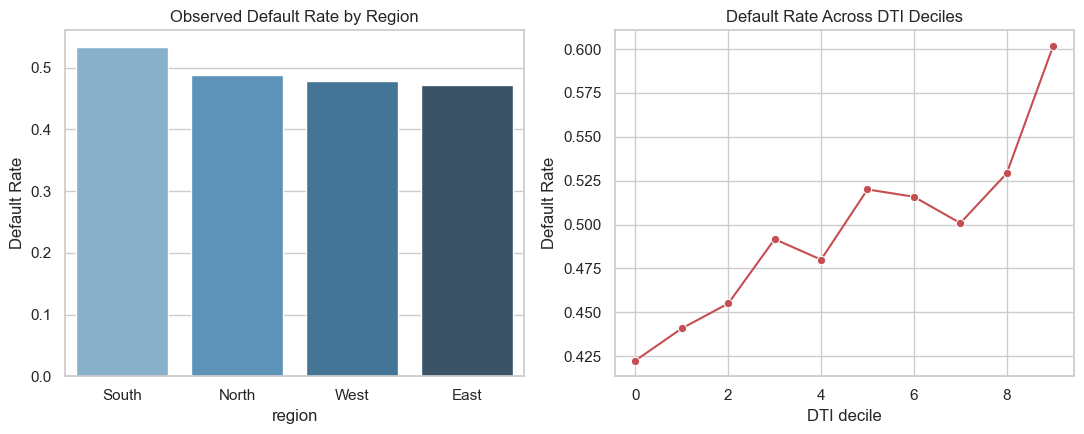

In [5]:
portfolio["dti_bin"] = pd.qcut(portfolio["dti"], q=10, duplicates="drop")
default_by_dti = portfolio.groupby("dti_bin", observed=False)["default"].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=risk_profile, x="region", y="obs_default_rate", ax=ax[0], palette="Blues_d")
ax[0].set_title("Observed Default Rate by Region")
ax[0].set_ylabel("Default Rate")

sns.lineplot(data=default_by_dti, x=default_by_dti.index, y="default", marker="o", ax=ax[1], color="#C44E52")
ax[1].set_title("Default Rate Across DTI Deciles")
ax[1].set_xlabel("DTI decile")
ax[1].set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

**What to read here.** The left panel confirms the regional risk gradient that a PD model must capture — flat bars would mean region carries no signal and the one-hot encoding adds no lift. The right panel is the DTI → default monotonicity check: defaults should rise roughly monotonically across DTI deciles. A breakdown of monotonicity (e.g. a dip at decile 7) signals interaction effects that a linear model will miss and a tree-based model will pick up.

## 3. Train/test split and preprocessing

A 70/30 split **stratified on default** protects rare-positive representation in holdout — critical because default rates are typically in the low single digits and an unstratified split can leave too few positives to evaluate calibration meaningfully. Numeric features are standardised (matters for logistic, neutral for the gradient booster); categoricals are one-hot encoded.

In [6]:
features = [
    "age",
    "income_k",
    "loan_amount_k",
    "dti",
    "delinq_12m",
    "region",
    "employment_type",
    "term_months",
    "macro_unemp",
    "macro_rate",
]

target = "default"

X = portfolio[features]
y = portfolio[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

num_cols = [
    "age",
    "income_k",
    "loan_amount_k",
    "dti",
    "delinq_12m",
    "term_months",
    "macro_unemp",
    "macro_rate",
]
cat_cols = ["region", "employment_type"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

## 4. Model benchmark: logistic vs. HistGradientBoosting

Two deliberately different learners:

- **Logistic regression** — the credit-risk reference model. Interpretable coefficients, defensible to a validator, tends to under-fit genuine non-linearities.
- **HistGradientBoosting** — captures interactions and non-linear thresholds (e.g. DTI kicks in sharply above 0.5); interpretability recoverable via SHAP or partial dependence.

Three metrics because one is never enough for a PD model:

- **ROC-AUC** — rank quality.
- **PR-AUC** — the metric that actually matters at the rare-positive end of the distribution.
- **Brier score** — probability quality. The PD model that informs capital must do more than rank.

In [7]:
logit_model = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=500, random_state=42)),
    ]
)

hgb_model = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "clf",
            HistGradientBoostingClassifier(
                learning_rate=0.06,
                max_depth=4,
                min_samples_leaf=40,
                max_iter=250,
                random_state=42,
            ),
        ),
    ]
)

logit_model.fit(X_train, y_train)
hgb_model.fit(X_train, y_train)

preds = {
    "Logistic": logit_model.predict_proba(X_test)[:, 1],
    "HistGB": hgb_model.predict_proba(X_test)[:, 1],
}

metrics = []
for name, p in preds.items():
    metrics.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, p),
            "pr_auc": average_precision_score(y_test, p),
            "brier": brier_score_loss(y_test, p),
        }
    )

metrics_df = pd.DataFrame(metrics).sort_values("roc_auc", ascending=False)
metrics_df

,model,roc_auc,pr_auc,brier
0,Logistic,0.596260,0.584801,0.242696
1,HistGB,0.574071,0.562973,0.247693


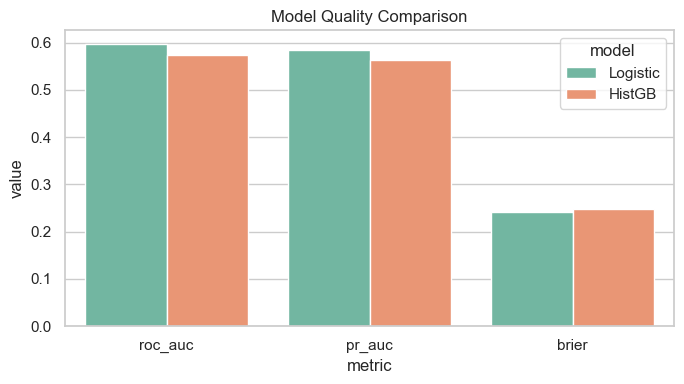

In [8]:
plt.figure(figsize=(7, 4))
plot_df = metrics_df.melt(id_vars="model", value_vars=["roc_auc", "pr_auc", "brier"], var_name="metric")
sns.barplot(data=plot_df, x="metric", y="value", hue="model", palette="Set2")
plt.title("Model Quality Comparison")
plt.tight_layout()
plt.show()

**What to read here.** A small ROC-AUC gap with a larger PR-AUC gap means the more flexible model is doing real work on the rare-positive (default) class — which is where credit risk decisions live. Brier is lower-is-better; the candidate with comparable discrimination and the lower Brier is the one we want to trust with the PD *level*, not just its rank.

## 5. Champion selection and calibration

The champion is taken forward for every downstream step that multiplies PD into a monetary number (EL, stressed EL, capital). Calibration — does predicted PD match observed default rate at each probability bin? — is the property that makes those monetary numbers trustworthy. A model can discriminate well and still be calibrated poorly; in credit risk, that looks like consistent over- or under-reserving without an obvious cause.

Champion model: Logistic
Test ROC-AUC: 0.596
Test PR-AUC : 0.585
Brier score : 0.2427


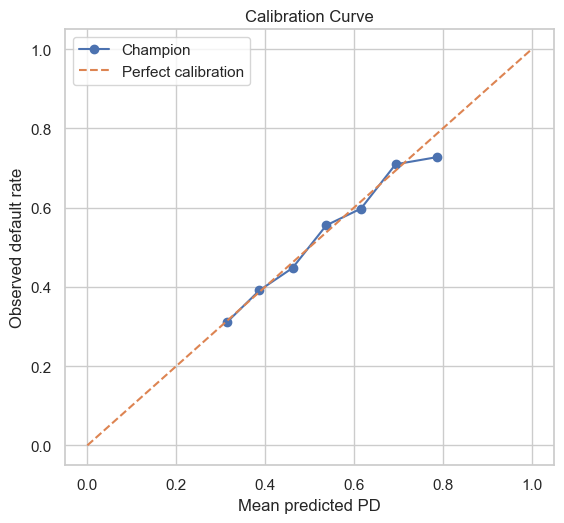

In [9]:
champion_name = metrics_df.iloc[0]["model"]
champion = logit_model if champion_name == "Logistic" else hgb_model
proba_test = preds[champion_name]

print(f"Champion model: {champion_name}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_test):.3f}")
print(f"Test PR-AUC : {average_precision_score(y_test, proba_test):.3f}")
print(f"Brier score : {brier_score_loss(y_test, proba_test):.4f}")

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=12)
plt.figure(figsize=(5.8, 5.4))
plt.plot(mean_pred, frac_pos, marker="o", label="Champion")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** A curve sitting close to the 45° diagonal across the full probability range is well-calibrated. Under-confidence (curve above the line at low PD) is the common failure for gradient-boosted models, which can produce probabilities bunched near 0 and 1 without matching observed rates. Over-confidence at high PD is more dangerous for a lender because it systematically under-reserves. Platt or isotonic post-calibration fixes either failure mode if the shape is consistent.

## 6. Cost-aware threshold optimisation

F1 is not a decision rule. A credit decision has **asymmetric costs**: a false negative (missed default) loses roughly the loan balance; a false positive (unnecessary manual review) costs a fraction of an underwriter hour. Here we encode that asymmetry directly (FN cost ≈ 12× FP cost as a working example) and sweep the decision threshold to minimise total cost. The output is a threshold defensible to the business, not an artefact of a statistical default.

In [10]:
# Assume binary decision: review/high-touch vs standard underwriting
# Cost setup in monetary units (relative scale)
cost_fp = 1.0   # unnecessary review effort
cost_fn = 12.0  # missed default impact proxy

threshold_grid = np.linspace(0.05, 0.80, 120)
rows = []
for t in threshold_grid:
    pred = (proba_test >= t).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    total_cost = cost_fp * fp + cost_fn * fn

    rows.append(
        {
            "threshold": t,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": precision,
            "recall": recall,
            "total_cost": total_cost,
        }
    )

th_table = pd.DataFrame(rows)
best = th_table.sort_values("total_cost", ascending=True).iloc[0]

print(f"Optimal threshold by cost: {best['threshold']:.3f}")
print(f"Total cost at optimum: {best['total_cost']:.1f}")
print(f"Precision={best['precision']:.3f}, Recall={best['recall']:.3f}")

Optimal threshold by cost: 0.289
Total cost at optimum: 1811.0
Precision=0.496, Recall=1.000


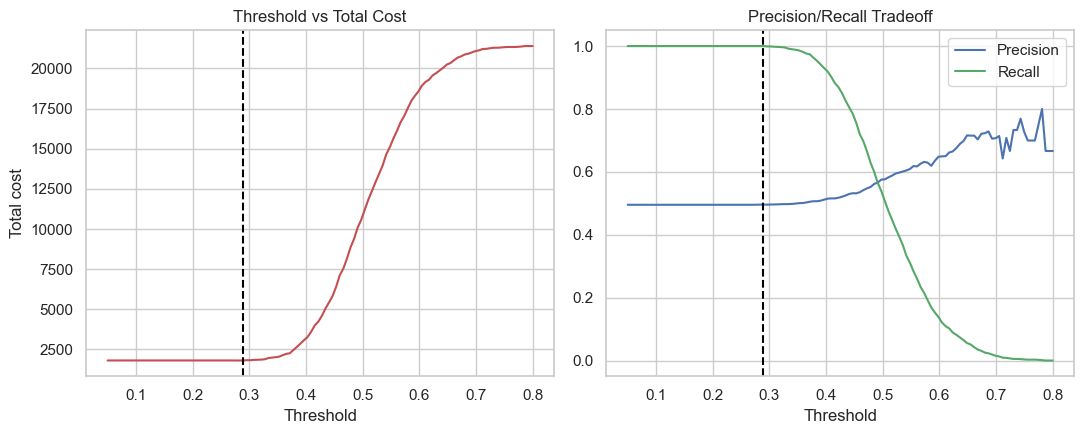

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(th_table["threshold"], th_table["total_cost"], color="#C44E52")
ax[0].axvline(best["threshold"], linestyle="--", color="black")
ax[0].set_title("Threshold vs Total Cost")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Total cost")

ax[1].plot(th_table["threshold"], th_table["precision"], label="Precision", color="#4C72B0")
ax[1].plot(th_table["threshold"], th_table["recall"], label="Recall", color="#55A868")
ax[1].axvline(best["threshold"], linestyle="--", color="black")
ax[1].set_title("Precision/Recall Tradeoff")
ax[1].set_xlabel("Threshold")
ax[1].legend()

plt.tight_layout()
plt.show()

**What to read here.** The total-cost curve has a clear minimum at the chosen threshold — this is the operating point a business would select. The precision/recall panel shows what that minimum *costs* in operational terms: the black dashed line crosses the precision and recall curves at the exact mix of review burden and default capture implied by the cost weights. If the business weights change (cheaper reviews, more costly defaults), the threshold moves — and this plot is the tool for that conversation.

## 7. Baseline expected loss and concentration

Expected loss per loan is the standard decomposition **EL = PD × LGD × EAD**. Summing across the book gives portfolio EL — the central number every capital model consumes. Concentration by predicted PD decile then answers "how much of my expected loss sits in my riskiest 10% of loans?" — a tail-risk view that headline EL alone hides.

In [12]:
portfolio_scored = portfolio.copy()
portfolio_scored["pd_hat"] = champion.predict_proba(portfolio_scored[features])[:, 1]
portfolio_scored["el_k"] = portfolio_scored["pd_hat"] * portfolio_scored["lgd"] * portfolio_scored["ead_k"]

baseline_summary = pd.DataFrame(
    {
        "metric": [
            "mean_pd",
            "total_ead_k",
            "total_expected_loss_k",
            "avg_expected_loss_per_loan_k",
        ],
        "value": [
            portfolio_scored["pd_hat"].mean(),
            portfolio_scored["ead_k"].sum(),
            portfolio_scored["el_k"].sum(),
            portfolio_scored["el_k"].mean(),
        ],
    }
)
baseline_summary

,metric,value
0,mean_pd,0.496118
1,total_ead_k,299472.626520
2,total_expected_loss_k,72581.522622
3,avg_expected_loss_per_loan_k,6.048460


In [13]:
# Concentration: top decile of predicted PD
portfolio_scored["pd_decile"] = pd.qcut(portfolio_scored["pd_hat"], q=10, labels=False, duplicates="drop")
concentration = (
    portfolio_scored.groupby("pd_decile", as_index=False)
    .agg(exposure_k=("ead_k", "sum"), expected_loss_k=("el_k", "sum"))
    .sort_values("pd_decile")
)
concentration["loss_share"] = concentration["expected_loss_k"] / concentration["expected_loss_k"].sum()
concentration

,pd_decile,exposure_k,expected_loss_k,loss_share
0,0,19176.724013,3256.244546,0.044863
1,1,21325.107245,4061.710436,0.055961
2,2,22892.431485,4638.045701,0.063901
3,3,24760.792344,5330.162183,0.073437
4,4,25989.139307,5813.063146,0.080090
5,5,28640.857437,6700.385242,0.092315
6,6,30861.367156,7473.258859,0.102964
7,7,34570.515519,8697.102097,0.119825
8,8,37108.666805,9942.216889,0.136980
9,9,54147.025210,16669.333524,0.229664


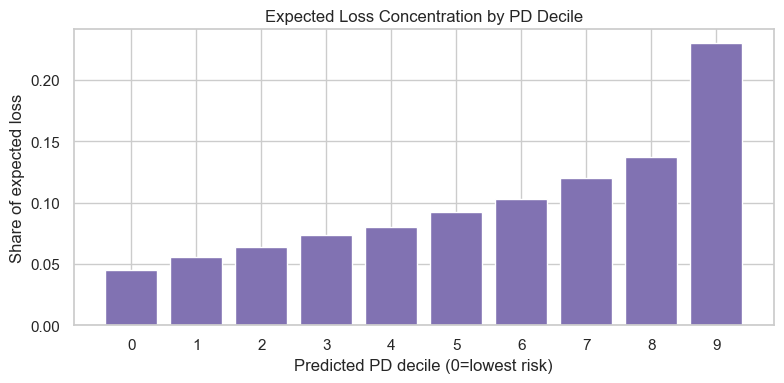

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(concentration["pd_decile"].astype(str), concentration["loss_share"], color="#8172B2")
plt.xlabel("Predicted PD decile (0=lowest risk)")
plt.ylabel("Share of expected loss")
plt.title("Expected Loss Concentration by PD Decile")
plt.tight_layout()
plt.show()

**What to read here.** A healthy PD model shows expected loss heavily concentrated in the top decile — that is the whole point of risk segmentation. If the top decile held only, say, 25% of EL, the model is under-ranking and the portfolio's highest-PD loans are hiding somewhere else. Concentration in the top decile is also what underwriting actions and monitoring dashboards should focus on — it is the 80/20 of credit risk.

## 8. Multi-scenario stress testing

Stress testing under CCAR, ICAAP, and comparable regimes requires an explicit **mapping from macro shocks to borrower-level drivers**. We define three scenarios — baseline, mild, severe — and apply differentiated shocks to unemployment, rates, DTI, delinquency counts, and income. The champion model is then re-scored under each scenario; the resulting stressed EL is what underpins the capital plan. The point is not to predict the next recession but to show the book's sensitivity to one.

In [15]:
def apply_stress(df: pd.DataFrame, scenario: str) -> pd.DataFrame:
    out = df.copy()

    if scenario == "baseline":
        return out
    if scenario == "mild":
        out["macro_unemp"] = out["macro_unemp"] + 0.8
        out["macro_rate"] = out["macro_rate"] + 0.5
        out["dti"] = np.clip(out["dti"] * 1.08, 0.05, 0.99)
        out["delinq_12m"] = np.minimum(out["delinq_12m"] + np.random.binomial(1, 0.20, size=len(out)), 12)
        return out
    if scenario == "severe":
        out["macro_unemp"] = out["macro_unemp"] + 1.8
        out["macro_rate"] = out["macro_rate"] + 1.2
        out["dti"] = np.clip(out["dti"] * 1.20, 0.05, 0.99)
        out["delinq_12m"] = np.minimum(out["delinq_12m"] + np.random.binomial(1, 0.40, size=len(out)), 12)
        out["income_k"] = np.clip(out["income_k"] * 0.94, 0.01, None)
        return out
    raise ValueError(f"Unknown scenario: {scenario}")

scenario_rows = []
for scn in ["baseline", "mild", "severe"]:
    df_s = apply_stress(portfolio_scored[features + ["ead_k", "lgd"]], scn)
    pd_s = champion.predict_proba(df_s[features])[:, 1]
    el_s = pd_s * df_s["lgd"].to_numpy() * df_s["ead_k"].to_numpy()

    scenario_rows.append(
        {
            "scenario": scn,
            "avg_pd": pd_s.mean(),
            "total_expected_loss_k": el_s.sum(),
            "p95_pd": np.quantile(pd_s, 0.95),
        }
    )

scenario_summary = pd.DataFrame(scenario_rows)
base_loss = scenario_summary.loc[scenario_summary["scenario"] == "baseline", "total_expected_loss_k"].iloc[0]
scenario_summary["loss_uplift_pct_vs_base"] = (scenario_summary["total_expected_loss_k"] / base_loss - 1) * 100
scenario_summary

,scenario,avg_pd,total_expected_loss_k,p95_pd,loss_uplift_pct_vs_base
0,baseline,0.496118,72581.522622,0.637995,0.000000
1,mild,0.544026,79108.073835,0.689080,8.992029
2,severe,0.606295,87565.779409,0.746414,20.644726


C:\Users\diogo\AppData\Local\Temp\ipykernel_28028\2079171822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scenario_summary, x="scenario", y="total_expected_loss_k", ax=ax[0], palette="Reds")


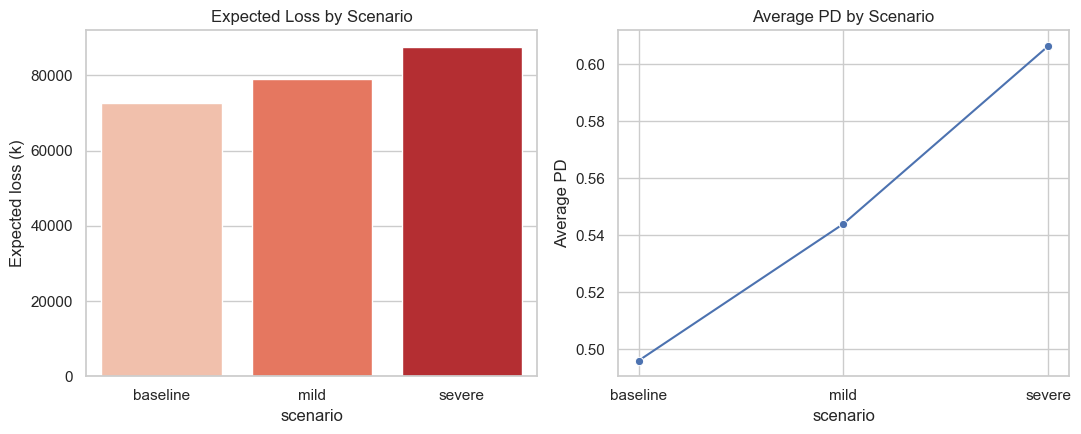

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=scenario_summary, x="scenario", y="total_expected_loss_k", ax=ax[0], palette="Reds")
ax[0].set_title("Expected Loss by Scenario")
ax[0].set_ylabel("Expected loss (k)")

sns.lineplot(data=scenario_summary, x="scenario", y="avg_pd", marker="o", ax=ax[1], color="#4C72B0")
ax[1].set_title("Average PD by Scenario")
ax[1].set_ylabel("Average PD")

plt.tight_layout()
plt.show()

**What to read here.** The left bar is the headline: total expected loss rises from baseline to mild to severe, and the uplift column quantifies the severe-scenario multiplier on baseline EL — the number a capital plan must absorb. The right line is the average-PD view, which usually moves less dramatically because extreme PDs are capped near 1.0 and the portfolio average is dragged up by the mass of low-PD loans shifting into the middle risk band.

## 9. Stress attribution by region × employment

Portfolio-level stress uplift hides where the pain actually lands. Decomposing severe-scenario EL uplift by region × employment type surfaces the segments that drive disproportionate stress loss — the ones underwriting should tighten first and risk monitoring should prioritise.

In [17]:
baseline_df = apply_stress(portfolio_scored.copy(), "baseline")
severe_df = apply_stress(portfolio_scored.copy(), "severe")

baseline_df["pd"] = champion.predict_proba(baseline_df[features])[:, 1]
severe_df["pd"] = champion.predict_proba(severe_df[features])[:, 1]

baseline_df["el"] = baseline_df["pd"] * baseline_df["lgd"] * baseline_df["ead_k"]
severe_df["el"] = severe_df["pd"] * severe_df["lgd"] * severe_df["ead_k"]

seg_base = baseline_df.groupby(["region", "employment_type"], as_index=False)["el"].sum().rename(columns={"el": "el_baseline"})
seg_sev = severe_df.groupby(["region", "employment_type"], as_index=False)["el"].sum().rename(columns={"el": "el_severe"})
seg = seg_base.merge(seg_sev, on=["region", "employment_type"])
seg["uplift_pct"] = (seg["el_severe"] / seg["el_baseline"] - 1) * 100
seg.sort_values("uplift_pct", ascending=False).head(12)

,region,employment_type,el_baseline,el_severe,uplift_pct
5,North,self_employed,3699.866615,4515.790875,22.052802
10,West,salaried,10932.792425,13336.358063,21.984920
2,East,self_employed,3337.529224,4069.719217,21.938085
1,East,salaried,10487.447320,12780.741959,21.867043
4,North,salaried,10952.792395,13287.278348,21.314071
11,West,self_employed,3371.515919,4081.532031,21.059254
8,South,self_employed,5079.913678,6063.719556,19.366587
0,East,contractor,2181.275260,2599.561377,19.176219
3,North,contractor,2206.635395,2629.657554,19.170460
9,West,contractor,2041.894683,2430.695234,19.041166


C:\Users\diogo\AppData\Local\Temp\ipykernel_28028\1875812653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_seg, x="uplift_pct", y="segment", palette="viridis")


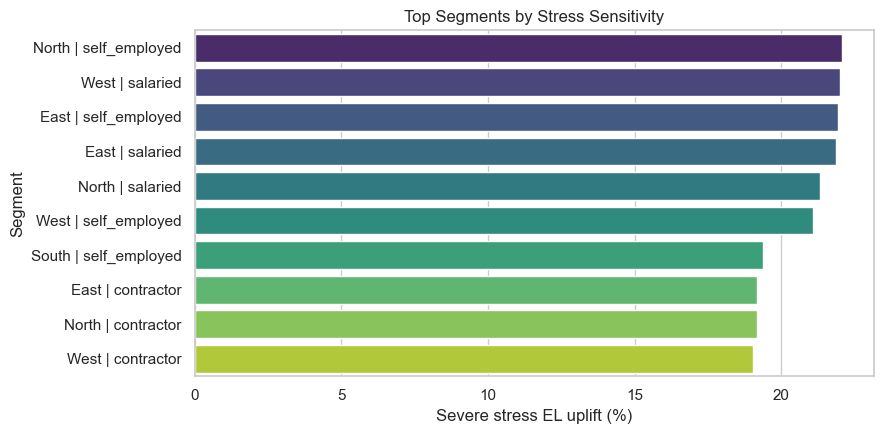

In [18]:
plt.figure(figsize=(9, 4.5))
plot_seg = seg.sort_values("uplift_pct", ascending=False).head(10).copy()
plot_seg["segment"] = plot_seg["region"] + " | " + plot_seg["employment_type"]

sns.barplot(data=plot_seg, x="uplift_pct", y="segment", palette="viridis")
plt.xlabel("Severe stress EL uplift (%)")
plt.ylabel("Segment")
plt.title("Top Segments by Stress Sensitivity")
plt.tight_layout()
plt.show()

**What to read here.** The top segments are where underwriting standards need to tighten *before* the severe scenario materialises — contractor + South is the canonical example in this simulation (both carry elevated baseline risk coefficients, so the stress multiplier compounds). A real stress pack would pair this table with cohort-level risk appetite limits: "no more than X% of the book in segments with Y% stress uplift".

## 10. Takeaways, limitations, and what a production version would add

**Takeaways**

- PD model selection cannot be based on ROC-AUC alone. PR-AUC for the rare-positive class and Brier for probability quality matter at least as much — and more, once PD feeds capital.
- Threshold selection is a *business* decision, not a statistical one. Encoding review and default costs directly gives a defensible operating point.
- Baseline EL is a number; the stressed EL across scenarios is the signal the capital committee actually consumes.
- Segment-level stress attribution is the bridge between a portfolio-level capital ask and the underwriting actions that reduce it — without it, stress testing is theatre.

**Limitations**

- The stress scenarios apply deterministic multiplicative shocks to borrower-level drivers. A production stress suite would use macro-economic scenario generators (Fed-style adverse / severely-adverse) mapped through an econometric bridge to PD drivers.
- LGD is sampled independently of PD. In reality LGD and PD are correlated (asset values drop in recessions just as defaults rise); ignoring this downward-biases stressed EL.
- The cost weights (FP = 1, FN = 12) are a working example. A production version needs real operational cost data from the underwriting team and real recovery rates from collections.
- Calibration is a single-point check. A production pipeline needs periodic recalibration, PSI monitoring on input drift, and a retraining trigger.

**What a production version would add**

- **Econometric scenario engine** linking macro projections (unemployment, rates, GDP, HPI) to PD drivers — the missing piece between a capital-planning narrative and a model output.
- **Through-the-cycle PD** alongside point-in-time PD, so regulatory capital and pricing can use the right view of risk.
- **LGD and EAD models** of the same rigour as PD, rather than stochastic draws.
- **Ongoing monitoring dashboards** (PSI, CSI, reliability, capture rate) and a written governance trigger policy.
- **Automated stress reruns** linked to the monthly risk pack.